# Climate Finance

**Motivation**: We want to determine if natural disasters creates financial stress

The results do not support a simple “disaster → immediate increase in delinquency” story. Instead, they suggest a more nuanced interpretation:

    - There is no clear positive contemporaneous effect on either Early_Delinquency_Rate or Late_Delinquency_Rate.

    - There is, however, a negative dynamic pattern in Early_Delinquency_Rate during the 1–4 months following severe events, especially for flood / flash flood events.

    - There is no evidence of pre-trends, which strengthens the credibility of the post-event pattern.

    - In prediction, future delinquency is explained mainly by its own persistence, and disasters seem to provide a smaller additional signal.

This suggests that, at least in this sample and at the county-month level, severe disasters do not immediately worsen early delinquency. Instead, they may be associated with a temporary reduction in early delinquency, consistent with mechanisms such as:

    - forbearance or temporary payment flexibility,

    - emergency public assistance,

    - insurance payouts,

    - administrative or credit reporting delays,



In [112]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from linearmodels.panel import PanelOLS


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from catboost import CatBoostRegressor


In [6]:
# Since we will work with different data sets and folders, let's set a working directory

wd_disaster="/Users/jsjaramillo/Desktop/1-Climate Finance Project/Data/1-Disaster/"

#wd_finance="/Users/jsjaramillo/Desktop/1-Climate Finance Project/Data/2-Finance/"

wd="/Users/jsjaramillo/Desktop/1-Climate Finance Project/Data/"

In [8]:
disaster_data = pd.read_stata(wd_disaster+"Disaster_Dataset_Cleaned.dta")  

finance_master = pd.read_stata(wd+"Finance_Disaster_Master.dta")  


In [10]:
disaster_data.head()

,FIPS_ST,STATENAME,FIPS_COUNTY,COUNTYNAME,fips,time,day,month,year,event_id,...,end_azimuth,end_location,begin_lat,begin_lon,end_lat,end_lon,episode_narrative,event_narrative,data_source,month_num
0,1,ALABAMA,1,AUTAUGA,1001,1982-01-01,3.0,January,1982,9977393,...,,,32.669998,-86.519997,NaN,NaN,,,PUB,1.0
1,1,ALABAMA,1,AUTAUGA,1001,1982-01-01,3.0,January,1982,9977392,...,,,32.680000,-86.570000,32.73,-86.550003,,,PUB,1.0
2,1,ALABAMA,1,AUTAUGA,1001,1982-04-01,26.0,April,1982,9978548,...,,,32.549999,-86.519997,32.57,-86.400002,,,PUB,4.0
3,1,ALABAMA,1,AUTAUGA,1001,1985-01-01,31.0,January,1985,9975700,...,,,32.430000,-86.529999,NaN,NaN,,,PUB,1.0
4,1,ALABAMA,1,AUTAUGA,1001,1995-03-01,7.0,March,1995,10314739,...,,,NaN,NaN,NaN,NaN,,Trees were downed on Interstate 65 near mile m...,CSV,3.0


In [12]:
finance_master.head()

,State,County,fips,time,Coastal_County,Early_Delinquency_Rate,Late_Delinquency_Rate,Event_Occur,Event_Id,Event_Type,...,Deaths_Indirect,Property_Damage_Value,Damage_Property,Damage_Crops,Injuries_Direct,Event_Narrative,Land_Area,Coastline_Region,Pop,Distance_To_Coast
0,AL,Baldwin County,1003,2008-01-01,Coastal,2.8,1.3,0.0,NaN,,...,NaN,NaN,,,NaN,,1589.780029,Gulf of Mexico,208563.0,21.3906
1,AL,Baldwin County,1003,2008-02-01,Coastal,3.1,1.2,0.0,NaN,,...,NaN,NaN,,,NaN,,1589.780029,Gulf of Mexico,208563.0,21.3906
2,AL,Baldwin County,1003,2008-03-01,Coastal,3.2,1.1,0.0,NaN,,...,NaN,NaN,,,NaN,,1589.780029,Gulf of Mexico,208563.0,21.3906
3,AL,Baldwin County,1003,2008-04-01,Coastal,2.5,1.3,0.0,NaN,,...,NaN,NaN,,,NaN,,1589.780029,Gulf of Mexico,208563.0,21.3906
4,AL,Baldwin County,1003,2008-05-01,Coastal,2.7,1.5,0.0,NaN,,...,NaN,NaN,,,NaN,,1589.780029,Gulf of Mexico,208563.0,21.3906


# Basic data cleaning



In [15]:
def prepare_monthly_panel(df, time_col="time", fips_col="fips"):
    """
    Returns a copy of df with:
    - parsed datetime column
    - month column normalized to month start
    - fips as string
    """
    out = df.copy()
    
    # Parse time
    out[time_col] = pd.to_datetime(out[time_col], errors="coerce")
    
    # FIPS as string (important to avoid dropping leading zeros)
    out[fips_col] = out[fips_col].astype(str).str.zfill(5)
    
    # Monthly time index
    out["month"] = out[time_col].dt.to_period("M").dt.to_timestamp()
    
    return out


# -----------------------------
def panel_diagnostics(df, fips_col="fips", month_col="month", name="dataset"):
    """
    Checks:
    - how many unique counties?
    - how many time periods?
    - is the panel balanced?
    - are there duplicate county-month rows?
    - are there missing months for some counties?
    """
    print(f"\n{'='*60}")
    print(f"Diagnostics for: {name}")
    print(f"{'='*60}")
    
    # Drop rows with missing county or month for diagnostics
    d = df.dropna(subset=[fips_col, month_col]).copy()
    
    # 1) Unique counties
    n_counties = d[fips_col].nunique()
    print(f"Unique counties: {n_counties}")
    
    # 2) Unique time periods
    n_periods = d[month_col].nunique()
    print(f"Unique time periods: {n_periods}")
    print(f"Date range: {d[month_col].min()} to {d[month_col].max()}")
    
    # 3) Duplicate county-month rows
    county_month_counts = d.groupby([fips_col, month_col]).size().rename("n_rows").reset_index()
    duplicates = county_month_counts[county_month_counts["n_rows"] > 1].sort_values("n_rows", ascending=False)
    
    print(f"Duplicate county-month rows: {len(duplicates)}")
    if len(duplicates) > 0:
        print("Top duplicate county-month combinations:")
        print(duplicates.head(10))
    
    # 4) Balanced panel check
    # For a strictly balanced panel, each county should appear in every month
    obs_per_county = d.drop_duplicates([fips_col, month_col]).groupby(fips_col)[month_col].nunique()
    balanced = obs_per_county.eq(n_periods).all()
    
    print(f"Balanced panel? {balanced}")
    print("Observation counts per county:")
    print(obs_per_county.describe())
    
    # 5) Missing months by county
    all_counties = d[fips_col].drop_duplicates().sort_values()
    all_months = pd.Series(pd.date_range(d[month_col].min(), d[month_col].max(), freq="MS"), name=month_col)
    
    full_index = pd.MultiIndex.from_product(
        [all_counties, all_months],
        names=[fips_col, month_col]
    )
    
    observed_index = d.drop_duplicates([fips_col, month_col]).set_index([fips_col, month_col]).index
    missing_index = full_index.difference(observed_index)
    
    missing_months = pd.DataFrame(index=missing_index).reset_index()
    print(f"Total missing county-month combinations: {len(missing_months)}")
    
    if len(missing_months) > 0:
        missing_summary = missing_months.groupby(fips_col).size().rename("n_missing_months").sort_values(ascending=False)
        print("Counties with most missing months:")
        print(missing_summary.head(10))
    else:
        missing_summary = pd.Series(dtype=int, name="n_missing_months")
    
    return {
        "n_counties": n_counties,
        "n_periods": n_periods,
        "balanced": balanced,
        "duplicates": duplicates,
        "missing_months": missing_months,
        "missing_summary": missing_summary,
        "obs_per_county": obs_per_county,
    }


# Disaster repetition check
# -----------------------------
def disaster_county_month_check(disaster_df, fips_col="fips", month_col="month", event_col="event_type"):
    """
    Checks whether multiple disasters occur in the same county-month.
    """
    d = disaster_df.dropna(subset=[fips_col, month_col]).copy()
    
    county_month_event_counts = (
        d.groupby([fips_col, month_col])
         .size()
         .rename("n_disasters")
         .reset_index()
         .sort_values("n_disasters", ascending=False)
    )
    
    multiple_disasters = county_month_event_counts[county_month_event_counts["n_disasters"] > 1]
    
    print(f"\n{'='*60}")
    print("Disaster county-month repetition check")
    print(f"{'='*60}")
    print(f"County-months with >1 disaster row: {len(multiple_disasters)}")
    
    if len(multiple_disasters) > 0:
        print("Top county-months with multiple disasters:")
        print(multiple_disasters.head(10))
    
    # Optional: see which event types co-occur in those county-months
    if len(multiple_disasters) > 0 and event_col in d.columns:
        merged = multiple_disasters.head(10).merge(
            d[[fips_col, month_col, event_col]],
            on=[fips_col, month_col],
            how="left"
        )
        print("\nExample event types in repeated county-months:")
        print(merged.sort_values([fips_col, month_col]))
    
    return {
        "county_month_event_counts": county_month_event_counts,
        "multiple_disasters": multiple_disasters
    }


#  Optional filtering for relevant disasters
# -----------------------------
def filter_target_disasters(disaster_df, damage_col="damage_property"):
    """
    Restrict to the disaster types you mentioned and optionally damage >= 500k.
    Adjust event labels if needed to match your actual data.
    """
    target_events = [
        "Hurricane",
        "Tornado",
        "Tropical Storm",
        "Thunderstorm",
        "Flood",
        "Winter Weather",  
        "Wildfire",
        "Hail"
    ]
    
    d = disaster_df.copy()
    
    # Standardize event_type a bit
    d["event_type"] = d["event_type"].astype(str).str.strip()
    
    # Keep only target events
    d = d[d["event_type"].isin(target_events)].copy()
    
    # If damage is already numeric, this works directly
    if damage_col in d.columns:
        d[damage_col] = pd.to_numeric(d[damage_col], errors="coerce")
        d = d[d[damage_col] >= 500_000]
    
    return d

In [17]:
# Prepare both datasets
finance_master_clean = prepare_monthly_panel(finance_master, time_col="time", fips_col="fips")
disaster_data_clean = prepare_monthly_panel(disaster_data, time_col="time", fips_col="fips")

# Finance panel diagnostics
finance_diag = panel_diagnostics(
    finance_master_clean,
    fips_col="fips",
    month_col="month",
    name="finance_master"
)

# Disaster panel diagnostics
disaster_diag = panel_diagnostics(
    disaster_data_clean,
    fips_col="fips",
    month_col="month",
    name="disaster_data"
)

# Check multiple disasters in same county-month
disaster_repeat = disaster_county_month_check(
    disaster_data_clean,
    fips_col="fips",
    month_col="month",
    event_col="event_type"
)


Diagnostics for: finance_master
Unique counties: 357
Unique time periods: 207
Date range: 2008-01-01 00:00:00 to 2025-03-01 00:00:00
Duplicate county-month rows: 0
Balanced panel? True
Observation counts per county:
count    357.0
mean     207.0
std        0.0
min      207.0
25%      207.0
50%      207.0
75%      207.0
max      207.0
Name: month, dtype: float64
Total missing county-month combinations: 0

Diagnostics for: disaster_data
Unique counties: 3114
Unique time periods: 539
Date range: 1980-01-01 00:00:00 to 2025-02-01 00:00:00
Duplicate county-month rows: 69463
Top duplicate county-month combinations:
         fips      month  n_rows
93351   36007 2021-07-01      68
6263    04013 2018-08-01      63
3437    01077 2021-05-01      59
6393    04015 2022-08-01      59
118893  42003 2013-07-01      59
45717   19153 2008-07-01      59
6285    04013 2022-08-01      51
3451    01077 2023-08-01      49
6262    04013 2018-07-01      48
118903  42003 2015-06-01      47
Balanced panel? Fal

We observe that finance_master is clean and model-ready, on the other hand disaster_data is not a panel in the same sense, we have several duplicate dates, or counties-months with more than one-disaster row.

The correct workflow is to restrict disasters to:

    - counties in finance_master

    - months in finance_master

    - selected disaster categories

- convert event-level rows into county-month summaries

- merge the aggregated disaster table into finance_master

In [20]:
def parse_damage(x):
    """
    Converts strings to numeric dollars.
    Examples:
        '25K' -> 25000
        '3.5M' -> 3500000
        '1B' -> 1000000000
        500000 -> 500000
    """
    if pd.isna(x):
        return np.nan
    
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)
    
    x = str(x).strip().upper().replace(",", "")
    
    if x in ["", "0", "0.00"]:
        return 0.0
    
    multipliers = {
        "K": 1_000,
        "M": 1_000_000,
        "B": 1_000_000_000
    }
    
    last = x[-1]
    if last in multipliers:
        try:
            return float(x[:-1]) * multipliers[last]
        except:
            return np.nan
    else:
        try:
            return float(x)
        except:
            return np.nan


def normalize_event_type(x):
    """
    Maps raw event labels into broader categories for your project.
    Adjust as needed after inspecting unique labels.
    """
    if pd.isna(x):
        return np.nan
    
    x = str(x).strip().lower()
    
    # Hurricane / tropical
    if "hurricane" in x:
        return "Hurricane"
    if "tropical storm" in x:
        return "Tropical Storm"
    
    # Tornado
    if "tornado" in x:
        return "Tornado"
    
    # Flood family
    if "flash flood" in x or x == "flood" or "coastal flood" in x:
        return "Flood"
    
    # Thunderstorm family
    if "thunderstorm" in x:
        return "Thunderstorm"
    
    # Winter weather family
    if "winter storm" in x or "winter weather" in x or "cold/wind chill" in x or "extreme cold" in x:
        return "Winter Weather"
    
    # Wildfire
    if "wildfire" in x:
        return "Wildfire"
    
    # Hail
    if "hail" in x:
        return "Hail"
    
    return "Other"

In [22]:
finance = finance_master_clean.copy()
disasters = disaster_data_clean.copy()

finance_counties = set(finance["fips"].unique())
finance_min_month = finance["month"].min()
finance_max_month = finance["month"].max()

# We are selecting only the rows where counti-month are also in finance_master data set
disasters_sub = disasters[
    disasters["fips"].isin(finance_counties) &
    disasters["month"].between(finance_min_month, finance_max_month)
].copy()

print("Disaster rows after restricting to finance counties and months:", len(disasters_sub))
print("Unique counties after restriction:", disasters_sub["fips"].nunique())
print("Date range:", disasters_sub["month"].min(), "to", disasters_sub["month"].max())

Disaster rows after restricting to finance counties and months: 36721
Unique counties after restriction: 355
Date range: 2008-01-01 00:00:00 to 2025-02-01 00:00:00


In [24]:
# Parse damages
disasters_sub["damage_property_num"] = disasters_sub["damage_property"].apply(parse_damage) \
    if "damage_property" in disasters_sub.columns else np.nan

disasters_sub["damage_crops_num"] = disasters_sub["damage_crops"].apply(parse_damage) \
    if "damage_crops" in disasters_sub.columns else 0.0

disasters_sub["damage_property_num"] = disasters_sub["damage_property_num"].fillna(0)
disasters_sub["damage_crops_num"] = disasters_sub["damage_crops_num"].fillna(0)

disasters_sub["total_damage"] = (
    disasters_sub["damage_property_num"] + disasters_sub["damage_crops_num"]
)

# Standardize event types
disasters_sub["event_type_grouped"] = disasters_sub["event_type"].apply(normalize_event_type)

# Quick check
print(disasters_sub["event_type_grouped"].value_counts(dropna=False))

event_type_grouped
Thunderstorm    24984
Flood            5856
Other            2618
Tornado          1817
Hail             1446
Name: count, dtype: int64


In [26]:
#Restrict our data to some disaster events and some threshold of damages
target_types = [
    "Hurricane",
    "Tornado",
    "Tropical Storm",
    "Thunderstorm",
    "Flood",
    "Winter Weather",
    "Wildfire",
    "Hail"
]

disasters_filtered = disasters_sub[
    disasters_sub["event_type_grouped"].isin(target_types)
].copy()

# Baseline threshold
disasters_filtered_500k = disasters_filtered[
    disasters_filtered["total_damage"] >= 500_000
].copy()

print("Rows after type filter:", len(disasters_filtered))
print("Rows after type + 500k threshold:", len(disasters_filtered_500k))
print(disasters_filtered_500k["event_type_grouped"].value_counts())

Rows after type filter: 34103
Rows after type + 500k threshold: 1405
event_type_grouped
Flood           690
Tornado         348
Thunderstorm    231
Hail            136
Name: count, dtype: int64


In [28]:
# Main county-month aggregation
disaster_monthly = (
    disasters_filtered_500k
    .groupby(["fips", "month"], as_index=False)
    .agg(
        n_disasters=("event_type_grouped", "size"),
        total_damage=("total_damage", "sum"),
        max_damage=("total_damage", "max"),
        n_hurricane=("event_type_grouped", lambda s: (s == "Hurricane").sum()),
        n_tornado=("event_type_grouped", lambda s: (s == "Tornado").sum()),
        n_tropical_storm=("event_type_grouped", lambda s: (s == "Tropical Storm").sum()),
        n_thunderstorm=("event_type_grouped", lambda s: (s == "Thunderstorm").sum()),
        n_flood=("event_type_grouped", lambda s: (s == "Flood").sum()),
        n_winter_weather=("event_type_grouped", lambda s: (s == "Winter Weather").sum()),
        n_wildfire=("event_type_grouped", lambda s: (s == "Wildfire").sum()),
        n_hail=("event_type_grouped", lambda s: (s == "Hail").sum()),
        injuries_direct=("injuries_direct", "sum") if "injuries_direct" in disasters_filtered_500k.columns else ("event_type_grouped", "size"),
        injuries_indirect=("injuries_indirect", "sum") if "injuries_indirect" in disasters_filtered_500k.columns else ("event_type_grouped", "size"),
        deaths_direct=("deaths_direct", "sum") if "deaths_direct" in disasters_filtered_500k.columns else ("event_type_grouped", "size"),
        deaths_indirect=("deaths_indirect", "sum") if "deaths_indirect" in disasters_filtered_500k.columns else ("event_type_grouped", "size")
    )
)

disaster_monthly["event_occur"] = 1
disaster_monthly["log_total_damage"] = np.log1p(disaster_monthly["total_damage"])

print(disaster_monthly.head())
print("County-month rows in aggregated disaster table:", len(disaster_monthly))

    fips      month  n_disasters  total_damage   max_damage  n_hurricane  \
0  01003 2014-04-01            1    27000000.0   27000000.0            0   
1  01003 2017-01-01            2     1550000.0     950000.0            0   
2  01073 2008-02-01            1     1000000.0    1000000.0            0   
3  01073 2011-04-01            3   723300000.0  700000000.0            0   
4  01073 2023-12-01            1     5000000.0    5000000.0            0   

   n_tornado  n_tropical_storm  n_thunderstorm  n_flood  n_winter_weather  \
0          0                 0               0        1                 0   
1          0                 0               1        1                 0   
2          1                 0               0        0                 0   
3          3                 0               0        0                 0   
4          1                 0               0        0                 0   

   n_wildfire  n_hail  injuries_direct  injuries_indirect  deaths_direct  \
0   

In [34]:
# Merging the data sets
analysis_df = finance.merge(
    disaster_monthly,
    on=["fips", "month"],
    how="left"
)

# Fill untreated county-months with zeros, I am still not sure about this step, is there a better inputation?
fill_zero_cols = [
    "n_disasters", "total_damage", "max_damage", "event_occur", "log_total_damage",
    "n_hurricane", "n_tornado", "n_tropical_storm", "n_thunderstorm",
    "n_flood", "n_winter_weather", "n_wildfire", "n_hail",
    "injuries_direct", "injuries_indirect", "deaths_direct", "deaths_indirect"
]

for col in fill_zero_cols:
    if col in analysis_df.columns:
        analysis_df[col] = analysis_df[col].fillna(0)

print(analysis_df.shape)
print("Share of treated county-months:", analysis_df["event_occur"].mean())

(73899, 42)
Share of treated county-months: 0.01457394552023708


# EDA

In [36]:
# Count number of treated and controled groups
analysis_df["event_occur"].value_counts(dropna=False)

event_occur
0.0    72822
1.0     1077
Name: count, dtype: int64

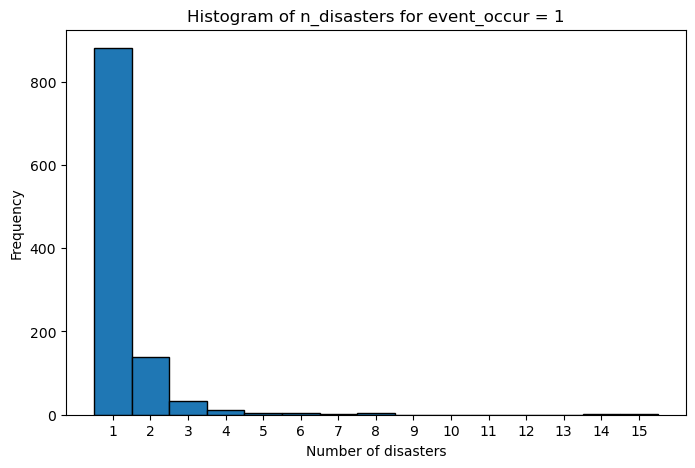

In [38]:
x = analysis_df.loc[analysis_df["event_occur"] == 1, "n_disasters"].dropna()

plt.figure(figsize=(8, 5))
plt.hist(x, bins=np.arange(x.min(), x.max() + 2) - 0.5, edgecolor="black")
plt.xlabel("Number of disasters")
plt.ylabel("Frequency")
plt.title("Histogram of n_disasters for event_occur = 1")
plt.xticks(range(int(x.min()), int(x.max()) + 1))
plt.show()

Is this something we should be concerned? 

In [40]:
# Top disasters
type_counts = {
    "Hurricane": analysis_df["n_hurricane"].sum(),
    "Tornado": analysis_df["n_tornado"].sum(),
    "Tropical Storm": analysis_df["n_tropical_storm"].sum(),
    "Thunderstorm": analysis_df["n_thunderstorm"].sum(),
    "Flood": analysis_df["n_flood"].sum(),
    "Winter Weather": analysis_df["n_winter_weather"].sum(),
    "Wildfire": analysis_df["n_wildfire"].sum(),
    "Hail": analysis_df["n_hail"].sum(),
}
print(pd.Series(type_counts).sort_values(ascending=False))

Flood             690.0
Tornado           348.0
Thunderstorm      231.0
Hail              136.0
Hurricane           0.0
Tropical Storm      0.0
Winter Weather      0.0
Wildfire            0.0
dtype: float64


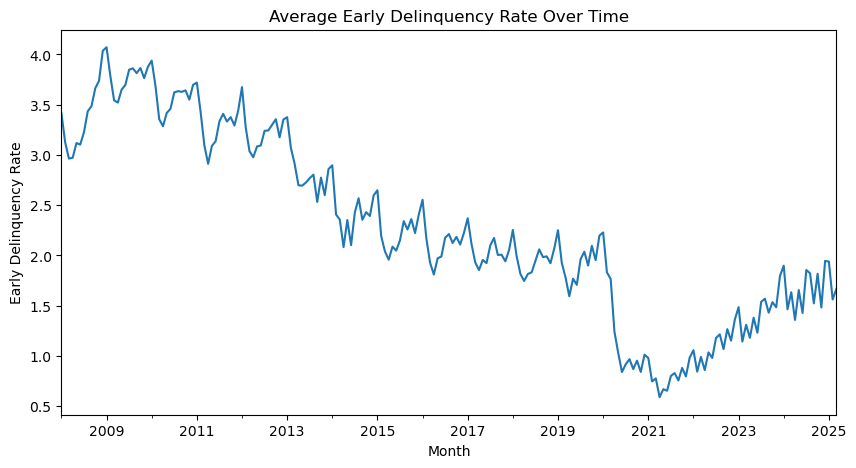

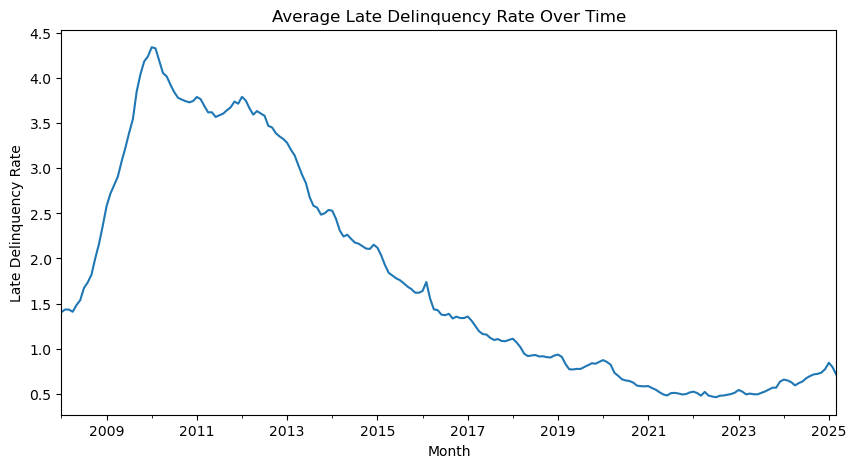

In [42]:
# average delinquency over time

monthly_avg=analysis_df.groupby("month")[["Early_Delinquency_Rate", "Late_Delinquency_Rate"]].mean()

monthly_avg["Early_Delinquency_Rate"].plot(figsize=(10, 5))
plt.title("Average Early Delinquency Rate Over Time")
plt.ylabel("Early Delinquency Rate")
plt.xlabel("Month")
plt.show()

monthly_avg["Late_Delinquency_Rate"].plot(figsize=(10, 5))
plt.title("Average Late Delinquency Rate Over Time")
plt.ylabel("Late Delinquency Rate")
plt.xlabel("Month")
plt.show()

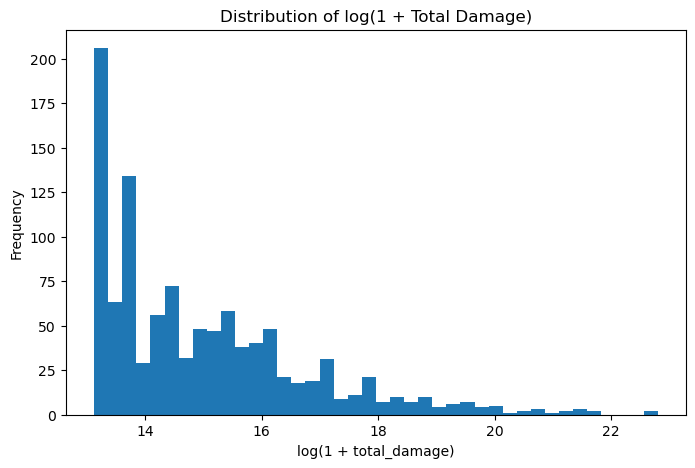

In [44]:
#damage histogram on log scale


treated_damage = analysis_df.loc[analysis_df["event_occur"] == 1, "total_damage"]

plt.figure(figsize=(8, 5))
plt.hist(np.log1p(treated_damage), bins=40)
plt.title("Distribution of log(1 + Total Damage)")
plt.xlabel("log(1 + total_damage)")
plt.ylabel("Frequency")
plt.show()

# Log scale is best since most of the losses reported are closed to 0

             Early_Delinquency_Rate  Late_Delinquency_Rate
event_occur                                               
0.0                        2.276639               1.772691
1.0                        2.501114               1.891644


<Figure size 800x500 with 0 Axes>

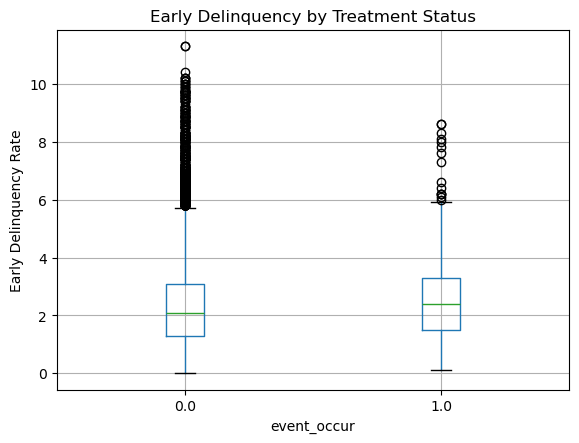

<Figure size 800x500 with 0 Axes>

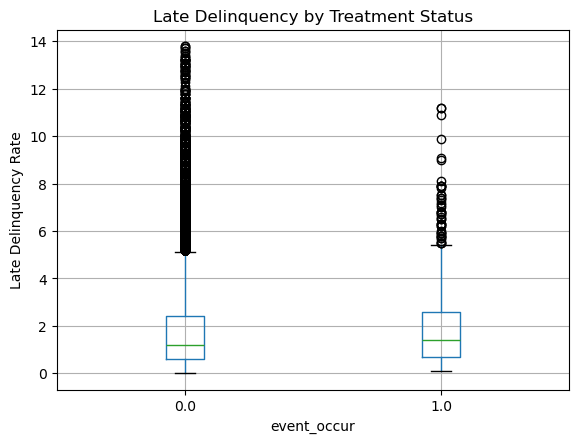

In [46]:
#mean delinquency in treated vs untreated county-months

comparison = analysis_df.groupby("event_occur")[["Early_Delinquency_Rate", "Late_Delinquency_Rate"]].mean()
print(comparison)


plt.figure(figsize=(8, 5))
analysis_df.boxplot(column="Early_Delinquency_Rate", by="event_occur")
plt.title("Early Delinquency by Treatment Status")
plt.suptitle("")
plt.xlabel("event_occur")
plt.ylabel("Early Delinquency Rate")
plt.show()

plt.figure(figsize=(8, 5))
analysis_df.boxplot(column="Late_Delinquency_Rate", by="event_occur")
plt.title("Late Delinquency by Treatment Status")
plt.suptitle("")
plt.xlabel("event_occur")
plt.ylabel("Late Delinquency Rate")
plt.show()

# We have a lots of outliers

In [48]:
# How many counties are ever treated?
treated_counties = analysis_df.loc[analysis_df["event_occur"] == 1, "fips"].nunique()
print("Counties ever treated:", treated_counties)
print("Share of counties ever treated:", treated_counties / analysis_df["fips"].nunique())

Counties ever treated: 320
Share of counties ever treated: 0.896358543417367


In [52]:
# Counties that experienced most events
county_treatment_counts = (
    analysis_df.groupby("fips")["event_occur"]
    .sum()
    .sort_values(ascending=False)
)

print(county_treatment_counts.describe())
print(county_treatment_counts.head(20))

count    357.000000
mean       3.016807
std        2.484728
min        0.000000
25%        1.000000
50%        2.000000
75%        4.000000
max       15.000000
Name: event_occur, dtype: float64
fips
48303    15.0
28121    15.0
47037    13.0
04019    13.0
48453    12.0
26081    10.0
47189     9.0
47125     9.0
12127     9.0
37183     9.0
13139     9.0
26163     9.0
39153     9.0
22015     9.0
37119     8.0
39151     8.0
48245     8.0
48061     8.0
29183     8.0
04025     8.0
Name: event_occur, dtype: float64


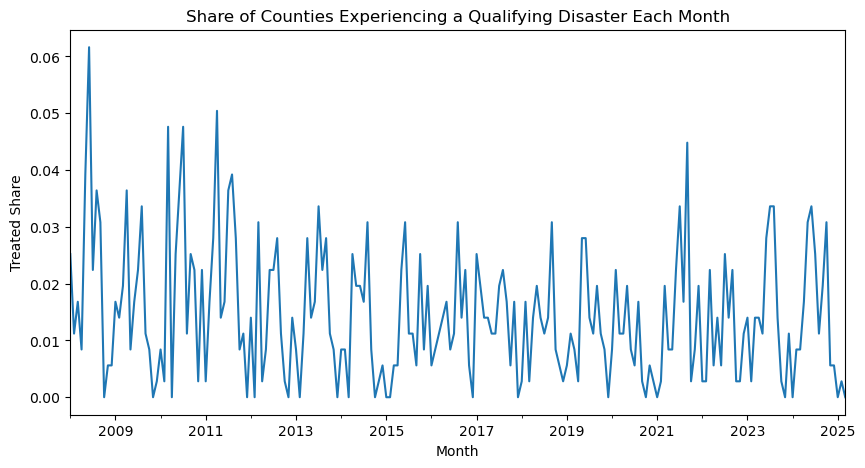

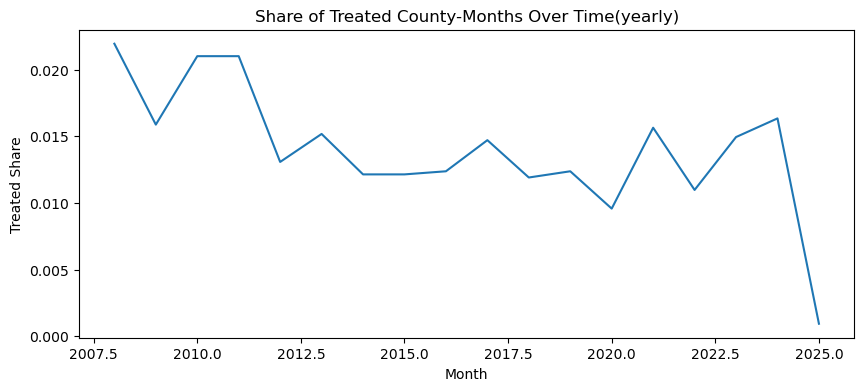

In [60]:
# Monthly treatment rate

monthly_treat = analysis_df.groupby("month")["event_occur"].mean()

yearly_treatment = analysis_df.groupby(analysis_df["month"].dt.year)["event_occur"].mean()

monthly_treat.plot(figsize=(10, 5))
plt.title("Share of Counties Experiencing a Qualifying Disaster Each Month")
plt.ylabel("Treated Share")
plt.xlabel("Month")
plt.show()

#yearly treatment rate
yearly_treatment.plot(figsize=(10, 4))
plt.title("Share of Treated County-Months Over Time(yearly)")
plt.ylabel("Treated Share")
plt.xlabel("Month")
plt.show()

Treatment is rare in time, but common across counties

- Only ~1.46% of county-months are treated

- About 89.6% of counties are treated at least once

This is an important design insight. Your identification will come mostly from:

 - within-county timing

 - not from a large pool of never-treated counties

That fits a fixed-effects framework well.

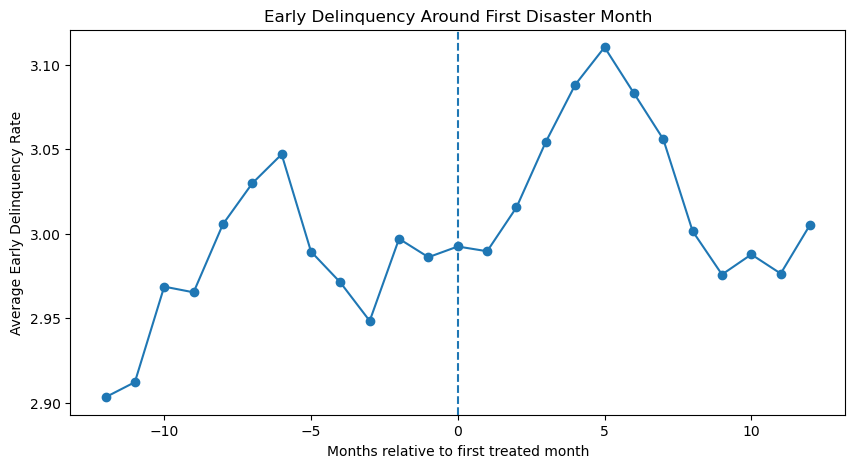

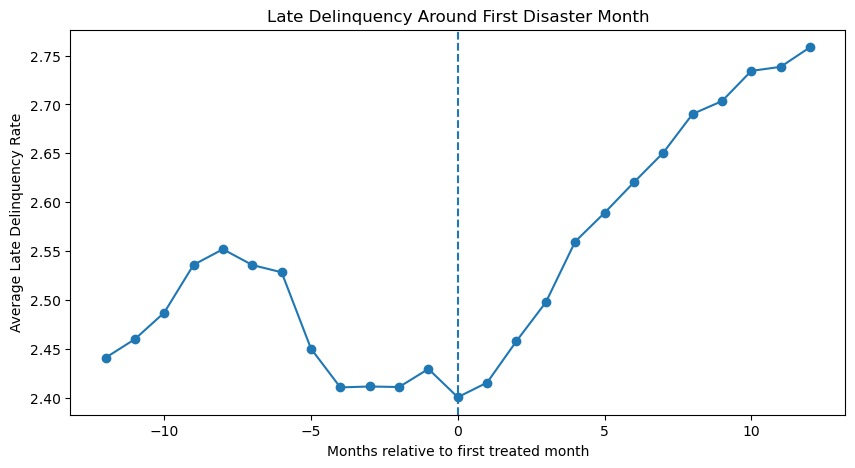

In [65]:
df = analysis_df.copy()
df["month"] = pd.to_datetime(df["month"])

# first treated month by county
first_treat = (
    df.loc[df["event_occur"] == 1]
    .groupby("fips")["month"]
    .min()
    .rename("first_treat_month")
)

df = df.merge(first_treat, on="fips", how="left")

# event time in months
df["event_time"] = (
    (df["month"].dt.year - df["first_treat_month"].dt.year) * 12 +
    (df["month"].dt.month - df["first_treat_month"].dt.month)
)

# keep window
event_window = df[df["event_time"].between(-12, 12)].copy()

# average outcomes by event time
es_early = event_window.groupby("event_time")["Early_Delinquency_Rate"].mean()
es_late = event_window.groupby("event_time")["Late_Delinquency_Rate"].mean()

plt.figure(figsize=(10, 5))
plt.plot(es_early.index, es_early.values, marker="o")
plt.axvline(0, linestyle="--")
plt.title("Early Delinquency Around First Disaster Month")
plt.xlabel("Months relative to first treated month")
plt.ylabel("Average Early Delinquency Rate")
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(es_late.index, es_late.values, marker="o")
plt.axvline(0, linestyle="--")
plt.title("Late Delinquency Around First Disaster Month")
plt.xlabel("Months relative to first treated month")
plt.ylabel("Average Late Delinquency Rate")
plt.show()

Let's normalize by county baseline, so cross-county level differences do not dominate.

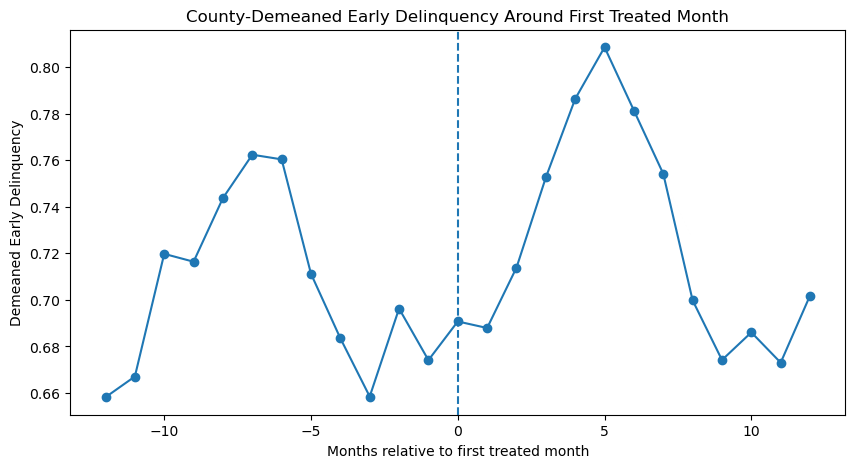

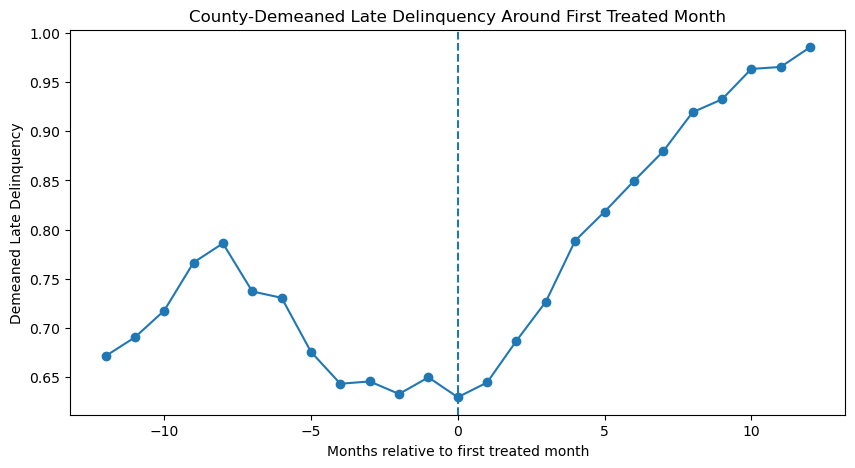

In [67]:
county_means = df.groupby("fips")[["Early_Delinquency_Rate", "Late_Delinquency_Rate"]].mean()
county_means = county_means.rename(columns={
    "Early_Delinquency_Rate": "Early_mean_county",
    "Late_Delinquency_Rate": "Late_mean_county"
})

df = df.merge(county_means, on="fips", how="left")
df["Early_demeaned"] = df["Early_Delinquency_Rate"] - df["Early_mean_county"]
df["Late_demeaned"] = df["Late_Delinquency_Rate"] - df["Late_mean_county"]

event_window = df[df["event_time"].between(-12, 12)].copy()

es_early_dm = event_window.groupby("event_time")["Early_demeaned"].mean()
es_late_dm = event_window.groupby("event_time")["Late_demeaned"].mean()

plt.figure(figsize=(10, 5))
plt.plot(es_early_dm.index, es_early_dm.values, marker="o")
plt.axvline(0, linestyle="--")
plt.title("County-Demeaned Early Delinquency Around First Treated Month")
plt.xlabel("Months relative to first treated month")
plt.ylabel("Demeaned Early Delinquency")
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(es_late_dm.index, es_late_dm.values, marker="o")
plt.axvline(0, linestyle="--")
plt.title("County-Demeaned Late Delinquency Around First Treated Month")
plt.xlabel("Months relative to first treated month")
plt.ylabel("Demeaned Late Delinquency")
plt.show()

This shows something very important:

- the treatment is rare over time,

- but fairly widespread across space.

That means identification does not come mainly from comparing treated counties to never-treated counties, but rather from within-county variation over time. That strongly supports a fixed effects approach.

# Inference

In [76]:
panel_df = analysis_df.copy()
panel_df["month"] = pd.to_datetime(panel_df["month"])
panel_df = panel_df.set_index(["fips", "month"]).sort_index()

In [78]:
y1 = panel_df["Early_Delinquency_Rate"]
X1 = panel_df[["event_occur"]]

# Early delinquency ~ event_occur

mod1 = PanelOLS(
    y1,
    X1,
    entity_effects=True,
    time_effects=True,
    drop_absorbed=True
)
res1 = mod1.fit(cov_type="clustered", cluster_entity=True)
print(res1.summary)

                            PanelOLS Estimation Summary                             
Dep. Variable:     Early_Delinquency_Rate   R-squared:                     3.915e-05
Estimator:                       PanelOLS   R-squared (Between):             -0.0003
No. Observations:                   73899   R-squared (Within):           -6.517e-05
Date:                    Sat, Mar 07 2026   R-squared (Overall):             -0.0003
Time:                            16:04:08   Log-likelihood                -4.694e+04
Cov. Estimator:                 Clustered                                           
                                            F-statistic:                      2.8710
Entities:                             357   P-value                           0.0902
Avg Obs:                           207.00   Distribution:                 F(1,73335)
Min Obs:                           207.00                                           
Max Obs:                           207.00   F-statistic (robust):

In [80]:
y2 = panel_df["Late_Delinquency_Rate"]
X2 = panel_df[["event_occur"]]

# Late delinquency ~ event_occur

mod2 = PanelOLS(
    y2,
    X2,
    entity_effects=True,
    time_effects=True,
    drop_absorbed=True
)
res2 = mod2.fit(cov_type="clustered", cluster_entity=True)
print(res2.summary)

                            PanelOLS Estimation Summary                            
Dep. Variable:     Late_Delinquency_Rate   R-squared:                      4.95e-06
Estimator:                      PanelOLS   R-squared (Between):             -0.0002
No. Observations:                  73899   R-squared (Within):           -2.376e-05
Date:                   Sat, Mar 07 2026   R-squared (Overall):             -0.0001
Time:                           16:04:22   Log-likelihood                -8.657e+04
Cov. Estimator:                Clustered                                           
                                           F-statistic:                      0.3630
Entities:                            357   P-value                           0.5469
Avg Obs:                          207.00   Distribution:                 F(1,73335)
Min Obs:                          207.00                                           
Max Obs:                          207.00   F-statistic (robust):            

Adding lags

In [88]:
panel_df = analysis_df.copy()
panel_df["month"] = pd.to_datetime(panel_df["month"])
panel_df = panel_df.set_index(["fips", "month"]).sort_index()

# 0 to 6 month lags of log damage
for k in range(1, 7):
    panel_df[f"log_total_damage_lag{k}"] = (
        panel_df.groupby(level=0)["log_total_damage"].shift(k).fillna(0)
    )

lag_cols = ["log_total_damage"] + [f"log_total_damage_lag{k}" for k in range(1, 7)]

mod_dl = PanelOLS(
    panel_df["Early_Delinquency_Rate"],
    panel_df[lag_cols],
    entity_effects=True,
    time_effects=True,
    drop_absorbed=True
)
res_dl = mod_dl.fit(cov_type="clustered", cluster_entity=True)
print(res_dl.summary)

                            PanelOLS Estimation Summary                             
Dep. Variable:     Early_Delinquency_Rate   R-squared:                        0.0009
Estimator:                       PanelOLS   R-squared (Between):             -0.0035
No. Observations:                   73899   R-squared (Within):              -0.0010
Date:                    Sat, Mar 07 2026   R-squared (Overall):             -0.0031
Time:                            16:11:22   Log-likelihood                -4.691e+04
Cov. Estimator:                 Clustered                                           
                                            F-statistic:                      9.4091
Entities:                             357   P-value                           0.0000
Avg Obs:                           207.00   Distribution:                 F(7,73329)
Min Obs:                           207.00                                           
Max Obs:                           207.00   F-statistic (robust):

The 1–4 month lags are negative and statistically significant:

    - lag 1: -0.0030

    - lag 2: -0.0036

    - lag 3: -0.0045

    - lag 4: -0.0033

while:

    - lags 5–6 are not significant

So larger disaster damage is followed by a temporary decline in early delinquency, peaking around 2–4 months later.

That pattern suggests:

greater disaster damage is associated with a temporary reduction in early delinquency in the 1–4 months following the event.

This is exactly the opposite of a story of immediate deterioration, which is why it initially felt surprising.

In [155]:
panel_df = analysis_df.copy()
panel_df["month"] = pd.to_datetime(panel_df["month"])
panel_df = panel_df.set_index(["fips", "month"]).sort_index()

# 0 to 6 month lags of log damage
for k in range(1, 7):
    panel_df[f"log_total_damage_lag{k}"] = (
        panel_df.groupby(level=0)["log_total_damage"].shift(k).fillna(0)
    )

mod_l_late = PanelOLS(
    panel_df["Late_Delinquency_Rate"],
    panel_df[lag_cols],
    entity_effects=True,
    time_effects=True,
    drop_absorbed=True
)
res_l_late = mod_l_late.fit(cov_type="clustered", cluster_entity=True)
print(res_l_late.summary)

                            PanelOLS Estimation Summary                            
Dep. Variable:     Late_Delinquency_Rate   R-squared:                     6.036e-05
Estimator:                      PanelOLS   R-squared (Between):             -0.0016
No. Observations:                  73899   R-squared (Within):              -0.0002
Date:                   Sat, Mar 07 2026   R-squared (Overall):             -0.0011
Time:                           17:39:53   Log-likelihood                -8.657e+04
Cov. Estimator:                Clustered                                           
                                           F-statistic:                      0.6324
Entities:                            357   P-value                           0.7295
Avg Obs:                          207.00   Distribution:                 F(7,73329)
Min Obs:                          207.00                                           
Max Obs:                          207.00   F-statistic (robust):            

Now, let's control by disaster type

In [158]:

panel_df["flood_occur"] = (panel_df["n_flood"] > 0).astype(int)
panel_df["tornado_occur"] = (panel_df["n_tornado"] > 0).astype(int)
panel_df["thunder_occur"] = (panel_df["n_thunderstorm"] > 0).astype(int)
panel_df["hail_occur"] = (panel_df["n_hail"] > 0).astype(int)

X_types = panel_df[[ "flood_occur"]]

mod_types = PanelOLS(
    panel_df["Early_Delinquency_Rate"],
    X_types,
    entity_effects=True,
    time_effects=True,
    drop_absorbed=True
)
res_types = mod_types.fit(cov_type="clustered", cluster_entity=True)
print(res_types.summary)

                            PanelOLS Estimation Summary                             
Dep. Variable:     Early_Delinquency_Rate   R-squared:                     8.288e-05
Estimator:                       PanelOLS   R-squared (Between):             -0.0003
No. Observations:                   73899   R-squared (Within):           -8.178e-05
Date:                    Sat, Mar 07 2026   R-squared (Overall):             -0.0003
Time:                            17:40:30   Log-likelihood                -4.694e+04
Cov. Estimator:                 Clustered                                           
                                            F-statistic:                      6.0788
Entities:                             357   P-value                           0.0137
Avg Obs:                           207.00   Distribution:                 F(1,73335)
Min Obs:                           207.00                                           
Max Obs:                           207.00   F-statistic (robust):

In [162]:
X_types = panel_df[[ "flood_occur"]]

mod_types = PanelOLS(
    panel_df["Late_Delinquency_Rate"],
    X_types,
    entity_effects=True,
    time_effects=True,
    drop_absorbed=True
)
res_types = mod_types.fit(cov_type="clustered", cluster_entity=True)
print(res_types.summary)

                            PanelOLS Estimation Summary                            
Dep. Variable:     Late_Delinquency_Rate   R-squared:                     1.035e-05
Estimator:                      PanelOLS   R-squared (Between):             -0.0002
No. Observations:                  73899   R-squared (Within):           -3.346e-05
Date:                   Sat, Mar 07 2026   R-squared (Overall):             -0.0001
Time:                           17:41:25   Log-likelihood                -8.657e+04
Cov. Estimator:                Clustered                                           
                                           F-statistic:                      0.7590
Entities:                            357   P-value                           0.3836
Avg Obs:                          207.00   Distribution:                 F(1,73335)
Min Obs:                          207.00                                           
Max Obs:                          207.00   F-statistic (robust):            

In [167]:
# Hail
X_types = panel_df[[ "hail_occur"]]

mod_types = PanelOLS(
    panel_df["Early_Delinquency_Rate"],
    X_types,
    entity_effects=True,
    time_effects=True,
    drop_absorbed=True
)
res_types = mod_types.fit(cov_type="clustered", cluster_entity=True)
print(res_types.summary)

X_types = panel_df[[ "hail_occur"]]

mod_types = PanelOLS(
    panel_df["Late_Delinquency_Rate"],
    X_types,
    entity_effects=True,
    time_effects=True,
    drop_absorbed=True
)
res_types = mod_types.fit(cov_type="clustered", cluster_entity=True)
print(res_types.summary)

                            PanelOLS Estimation Summary                             
Dep. Variable:     Early_Delinquency_Rate   R-squared:                     9.034e-05
Estimator:                       PanelOLS   R-squared (Between):              0.0001
No. Observations:                   73899   R-squared (Within):               0.0001
Date:                    Sat, Mar 07 2026   R-squared (Overall):              0.0001
Time:                            17:43:35   Log-likelihood                -4.694e+04
Cov. Estimator:                 Clustered                                           
                                            F-statistic:                      6.6260
Entities:                             357   P-value                           0.0101
Avg Obs:                           207.00   Distribution:                 F(1,73335)
Min Obs:                           207.00                                           
Max Obs:                           207.00   F-statistic (robust):

In [183]:
# Tornado
X_types = panel_df[[ "tornado_occur"]]

mod_types = PanelOLS(
    panel_df["Early_Delinquency_Rate"],
    X_types,
    entity_effects=True,
    time_effects=True,
    drop_absorbed=True
)
res_types = mod_types.fit(cov_type="clustered", cluster_entity=True)
print(res_types.summary)

X_types = panel_df[[ "tornado_occur"]]

mod_types = PanelOLS(
    panel_df["Late_Delinquency_Rate"],
    X_types,
    entity_effects=True,
    time_effects=True,
    drop_absorbed=True
)
res_types = mod_types.fit(cov_type="clustered", cluster_entity=True)
print(res_types.summary)

                            PanelOLS Estimation Summary                             
Dep. Variable:     Early_Delinquency_Rate   R-squared:                     1.278e-06
Estimator:                       PanelOLS   R-squared (Between):          -2.814e-05
No. Observations:                   73899   R-squared (Within):           -6.194e-06
Date:                    Sat, Mar 07 2026   R-squared (Overall):          -2.481e-05
Time:                            17:47:59   Log-likelihood                -4.694e+04
Cov. Estimator:                 Clustered                                           
                                            F-statistic:                      0.0938
Entities:                             357   P-value                           0.7595
Avg Obs:                           207.00   Distribution:                 F(1,73335)
Min Obs:                           207.00                                           
Max Obs:                           207.00   F-statistic (robust):

In [181]:
type_cols = ["flood_occur", "tornado_occur", "thunder_occur", "hail_occur"]

mod_types_early = PanelOLS(
    panel_df["Early_Delinquency_Rate"],
    panel_df[type_cols],
    entity_effects=True,
    time_effects=True,
    drop_absorbed=True
)

res_types_early = mod_types_early.fit(cov_type="clustered", cluster_entity=True)
print(res_types_early.summary)

mod_types_late = PanelOLS(
    panel_df["Late_Delinquency_Rate"],
    panel_df[type_cols],
    entity_effects=True,
    time_effects=True,
    drop_absorbed=True
)

res_types_late = mod_types_late.fit(cov_type="clustered", cluster_entity=True)
print(res_types_late.summary)

                            PanelOLS Estimation Summary                             
Dep. Variable:     Early_Delinquency_Rate   R-squared:                        0.0002
Estimator:                       PanelOLS   R-squared (Between):             -0.0003
No. Observations:                   73899   R-squared (Within):            6.504e-05
Date:                    Sat, Mar 07 2026   R-squared (Overall):             -0.0002
Time:                            17:46:14   Log-likelihood                -4.693e+04
Cov. Estimator:                 Clustered                                           
                                            F-statistic:                      4.0603
Entities:                             357   P-value                           0.0027
Avg Obs:                           207.00   Distribution:                 F(4,73332)
Min Obs:                           207.00                                           
Max Obs:                           207.00   F-statistic (robust):

In joint type-specific FE models, flood exposure is associated with a statistically significant decline in early delinquency, while no comparable effect appears for late delinquency. Tornado and hail do not show robust average effects, and thunderstorm exposure is only marginally associated with early delinquency.

From the previous results, we see a counterintuitive effect here: in most cases, although the estimates are statistically insignificant, the effects of disasters on default appear to be negative. I believe this may be driven by the combined noise across counties, which is why we should consider controlling for county-level factors.

In [186]:
df = analysis_df.copy()
df["month"] = pd.to_datetime(df["month"])

# flood indicator
df["flood_occur"] = (df["n_flood"] > 0).astype(int)

county_exposure = (
    df.groupby(["fips", "County"], as_index=False)
      .agg(
          total_damage_sum=("total_damage", "sum"),
          treated_months=("event_occur", "sum"),
          total_disaster_events=("n_disasters", "sum")
      )
)

top5 = county_exposure.sort_values("total_damage_sum", ascending=False).head(5)
print(top5)

top5_fips = top5["fips"].tolist()

      fips             County  total_damage_sum  treated_months  \
308  48157   Fort Bend County      8.008842e+09             6.0   
314  48339  Montgomery County      7.202165e+09             6.0   
311  48245   Jefferson County      3.328000e+09             8.0   
294  47037    Davidson County      2.736081e+09            13.0   
42   08059   Jefferson County      2.658000e+09             3.0   

     total_disaster_events  
308                   11.0  
314                    6.0  
311                    8.0  
294                   17.0  
42                     3.0  


In [188]:
df_int = df.copy()

for f in top5_fips:
    df_int[f"flood_x_{f}"] = ((df_int["fips"] == f).astype(int) * df_int["flood_occur"])

panel_int = df_int.set_index(["fips", "month"]).sort_index()

interaction_cols = ["flood_occur"] + [f"flood_x_{f}" for f in top5_fips]

In [190]:
mod_county_het = PanelOLS(
    panel_int["Early_Delinquency_Rate"],
    panel_int[interaction_cols],
    entity_effects=True,
    time_effects=True,
    drop_absorbed=True
)

res_county_het = mod_county_het.fit(cov_type="clustered", cluster_entity=True)
print(res_county_het.summary)

                            PanelOLS Estimation Summary                             
Dep. Variable:     Early_Delinquency_Rate   R-squared:                        0.0001
Estimator:                       PanelOLS   R-squared (Between):             -0.0003
No. Observations:                   73899   R-squared (Within):           -4.666e-05
Date:                    Sat, Mar 07 2026   R-squared (Overall):             -0.0003
Time:                            17:52:55   Log-likelihood                -4.694e+04
Cov. Estimator:                 Clustered                                           
                                            F-statistic:                      1.6576
Entities:                             357   P-value                           0.1270
Avg Obs:                           207.00   Distribution:                 F(6,73330)
Min Obs:                           207.00                                           
Max Obs:                           207.00   F-statistic (robust):

In [192]:
base_effect = res_county_het.params["flood_occur"]

rows = []
for f in top5_fips:
    interaction_name = f"flood_x_{f}"
    county_name = top5.loc[top5["fips"] == f, "County"].iloc[0]
    county_effect = base_effect + res_county_het.params.get(interaction_name, 0.0)

    rows.append({
        "fips": f,
        "County": county_name,
        "base_flood_effect": base_effect,
        "interaction": res_county_het.params.get(interaction_name, np.nan),
        "county_flood_effect": county_effect
    })

county_effects_table = pd.DataFrame(rows)
print(county_effects_table)

    fips             County  base_flood_effect  interaction  \
0  48157   Fort Bend County          -0.048108     0.098894   
1  48339  Montgomery County          -0.048108     0.073279   
2  48245   Jefferson County          -0.048108    -0.423335   
3  47037    Davidson County          -0.048108     0.042441   
4  08059   Jefferson County          -0.048108    -0.185861   

   county_flood_effect  
0             0.050786  
1             0.025171  
2            -0.471443  
3            -0.005666  
4            -0.233969  


This suggests that the effect of flood is not homogeneous across counties.

 - That is important because it complements what you had already found:

 - on average, flood is associated with a decline in Early_Delinquency_Rate, but that relationship varies substantially across counties,

 - some counties appear to show a more negative effect than the average, while others even show a positive effect.

# Modeling

In [ ]:
def build_prediction_dataset(df, target_col="Early_Delinquency_Rate", horizon=1):
    data = df.copy()
    data["month"] = pd.to_datetime(data["month"])
    data = data.sort_values(["fips", "month"]).copy()

    # ---------------------------
    # Basic event indicators
    # ---------------------------
    data["flood_occur"] = (data["n_flood"] > 0).astype(int)
    data["tornado_occur"] = (data["n_tornado"] > 0).astype(int)
    data["thunder_occur"] = (data["n_thunderstorm"] > 0).astype(int)
    data["hail_occur"] = (data["n_hail"] > 0).astype(int)

    # ---------------------------
    # Calendar features
    # ---------------------------
    data["month_num"] = data["month"].dt.month
    data["year"] = data["month"].dt.year
    data["quarter"] = data["month"].dt.quarter

    # ---------------------------
    # Lagged targets
    # ---------------------------
    for lag in [1, 2, 3, 6, 12]:
        data[f"{target_col}_lag{lag}"] = data.groupby("fips")[target_col].shift(lag)

    # Also include lagged late delinquency if predicting early
    other_target = "Late_Delinquency_Rate" if target_col == "Early_Delinquency_Rate" else "Early_Delinquency_Rate"
    for lag in [1, 2, 3, 6, 12]:
        data[f"{other_target}_lag{lag}"] = data.groupby("fips")[other_target].shift(lag)

    # ---------------------------
    # Lagged disaster features
    # ---------------------------
    lag_vars = [
        "event_occur", "log_total_damage", "n_disasters",
        "flood_occur", "tornado_occur", "thunder_occur", "hail_occur"
    ]

    for var in lag_vars:
        for lag in [1, 2, 3, 6]:
            data[f"{var}_lag{lag}"] = data.groupby("fips")[var].shift(lag).fillna(0)

    # ---------------------------
    # Rolling disaster exposure
    # Use only past/current information
    # ---------------------------
    g = data.groupby("fips")

    data["event_occur_roll3"] = (
        g["event_occur"].rolling(3, min_periods=1).sum().reset_index(level=0, drop=True)
    )
    data["event_occur_roll6"] = (
        g["event_occur"].rolling(6, min_periods=1).sum().reset_index(level=0, drop=True)
    )

    data["log_total_damage_roll3"] = (
        g["log_total_damage"].rolling(3, min_periods=1).sum().reset_index(level=0, drop=True)
    )
    data["log_total_damage_roll6"] = (
        g["log_total_damage"].rolling(6, min_periods=1).sum().reset_index(level=0, drop=True)
    )

    # ---------------------------
    # Next-month target
    # ---------------------------
    data["target"] = data.groupby("fips")[target_col].shift(-horizon)

    # ---------------------------
    # Keep rows with target available
    # ---------------------------
    data = data.dropna(subset=["target"]).copy()

    return data

In [ ]:
def temporal_split(df, date_col="month", test_months=12, valid_months=12):
    months = np.array(sorted(df[date_col].unique()))
    
    test_cut = months[-test_months:]
    valid_cut = months[-(test_months + valid_months):-test_months]
    train_cut = months[:-(test_months + valid_months)]

    train_df = df[df[date_col].isin(train_cut)].copy()
    valid_df = df[df[date_col].isin(valid_cut)].copy()
    test_df  = df[df[date_col].isin(test_cut)].copy()

    print("Train range:", train_df[date_col].min(), "to", train_df[date_col].max(), "| n =", len(train_df))
    print("Valid range:", valid_df[date_col].min(), "to", valid_df[date_col].max(), "| n =", len(valid_df))
    print("Test range: ", test_df[date_col].min(), "to", test_df[date_col].max(), "| n =", len(test_df))

    return train_df, valid_df, test_df

In [106]:
model_df = build_prediction_dataset(
    analysis_df,
    target_col="Early_Delinquency_Rate",
    horizon=1
)

train_df, valid_df, test_df = temporal_split(model_df, date_col="month", test_months=12, valid_months=12)

Train range: 2008-01-01 00:00:00 to 2023-02-01 00:00:00 | n = 64974
Valid range: 2023-03-01 00:00:00 to 2024-02-01 00:00:00 | n = 4284
Test range:  2024-03-01 00:00:00 to 2025-02-01 00:00:00 | n = 4284


In [108]:
categorical_cols = [
    "fips", "State", "County", "Coastal_County", "Coastline_Region", "month_num", "quarter"
]

feature_cols = [
    # static / slow-moving
    "fips", "State", "County", "Coastal_County", "Coastline_Region",
    "Land_Area", "Distance_To_Coast", "Pop",
    "month_num", "year", "quarter",

    # current disaster conditions
    "event_occur", "n_disasters", "log_total_damage",
    "flood_occur", "tornado_occur", "thunder_occur", "hail_occur",

    # lagged target information
    "Early_Delinquency_Rate_lag1", "Early_Delinquency_Rate_lag2",
    "Early_Delinquency_Rate_lag3", "Early_Delinquency_Rate_lag6",
    "Early_Delinquency_Rate_lag12",

    "Late_Delinquency_Rate_lag1", "Late_Delinquency_Rate_lag2",
    "Late_Delinquency_Rate_lag3", "Late_Delinquency_Rate_lag6",
    "Late_Delinquency_Rate_lag12",

    # lagged disasters
    "event_occur_lag1", "event_occur_lag2", "event_occur_lag3", "event_occur_lag6",
    "log_total_damage_lag1", "log_total_damage_lag2", "log_total_damage_lag3", "log_total_damage_lag6",
    "n_disasters_lag1", "n_disasters_lag2", "n_disasters_lag3", "n_disasters_lag6",
    "flood_occur_lag1", "flood_occur_lag2", "flood_occur_lag3", "flood_occur_lag6",
    "tornado_occur_lag1", "tornado_occur_lag2", "tornado_occur_lag3", "tornado_occur_lag6",
    "thunder_occur_lag1", "thunder_occur_lag2", "thunder_occur_lag3", "thunder_occur_lag6",
    "hail_occur_lag1", "hail_occur_lag2", "hail_occur_lag3", "hail_occur_lag6",

    # rolling exposure
    "event_occur_roll3", "event_occur_roll6",
    "log_total_damage_roll3", "log_total_damage_roll6",
]

# Keep only columns that actually exist
feature_cols = [c for c in feature_cols if c in model_df.columns]
categorical_cols = [c for c in categorical_cols if c in feature_cols]

X_train = train_df[feature_cols].copy()
y_train = train_df["target"].copy()

X_valid = valid_df[feature_cols].copy()
y_valid = valid_df["target"].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df["target"].copy()

print("Number of features:", len(feature_cols))

Number of features: 60


In [114]:
def evaluate_predictions(y_true, y_pred, name="model"):
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name}")
    print("RMSE:", round(rmse, 4))
    print("MAE: ", round(mae, 4))
    print("R2:  ", round(r2, 4))
    print("-" * 40)
    return {"model": name, "RMSE": rmse, "MAE": mae, "R2": r2}

# Naive baseline: next month ~= current month
naive_pred = test_df["Early_Delinquency_Rate"].values
baseline_metrics = evaluate_predictions(y_test, naive_pred, name="Naive baseline")

Naive baseline
RMSE: 0.4279
MAE:  0.3266
R2:   0.7365
----------------------------------------


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [116]:
cat_model = CatBoostRegressor(
    iterations=1500,
    learning_rate=0.03,
    depth=6,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=100
)

cat_model.fit(
    X_train,
    y_train,
    cat_features=categorical_cols,
    eval_set=(X_valid, y_valid),
    use_best_model=True
)

0:	learn: 1.2903765	test: 1.1026662	best: 1.1026662 (0)	total: 73ms	remaining: 1m 49s
100:	learn: 0.3665981	test: 0.3611080	best: 0.3591910 (98)	total: 1.49s	remaining: 20.6s
200:	learn: 0.3327240	test: 0.3255538	best: 0.3255465 (199)	total: 3.2s	remaining: 20.7s
300:	learn: 0.3238552	test: 0.3050424	best: 0.3050424 (300)	total: 4.86s	remaining: 19.4s
400:	learn: 0.3172567	test: 0.2969310	best: 0.2968712 (398)	total: 6.46s	remaining: 17.7s
500:	learn: 0.3126498	test: 0.2962159	best: 0.2959013 (472)	total: 7.93s	remaining: 15.8s
600:	learn: 0.3087440	test: 0.2950012	best: 0.2949925 (599)	total: 9.48s	remaining: 14.2s
700:	learn: 0.3053569	test: 0.2935555	best: 0.2935555 (700)	total: 11s	remaining: 12.5s
800:	learn: 0.3032093	test: 0.2925250	best: 0.2924750 (784)	total: 12.5s	remaining: 10.9s
900:	learn: 0.3009498	test: 0.2912486	best: 0.2912486 (900)	total: 14.1s	remaining: 9.37s
1000:	learn: 0.2989900	test: 0.2907302	best: 0.2907257 (999)	total: 15.7s	remaining: 7.84s
1100:	learn: 0.29

CatBoostRegressor(depth=6, eval_metric='RMSE', iterations=1500, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=100)

In [118]:
valid_pred = cat_model.predict(X_valid)
test_pred = cat_model.predict(X_test)

valid_metrics = evaluate_predictions(y_valid, valid_pred, name="CatBoost validation")
test_metrics = evaluate_predictions(y_test, test_pred, name="CatBoost test")

CatBoost validation
RMSE: 0.2879
MAE:  0.2118
R2:   0.8529
----------------------------------------
CatBoost test
RMSE: 0.3426
MAE:  0.2504
R2:   0.8311
----------------------------------------


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


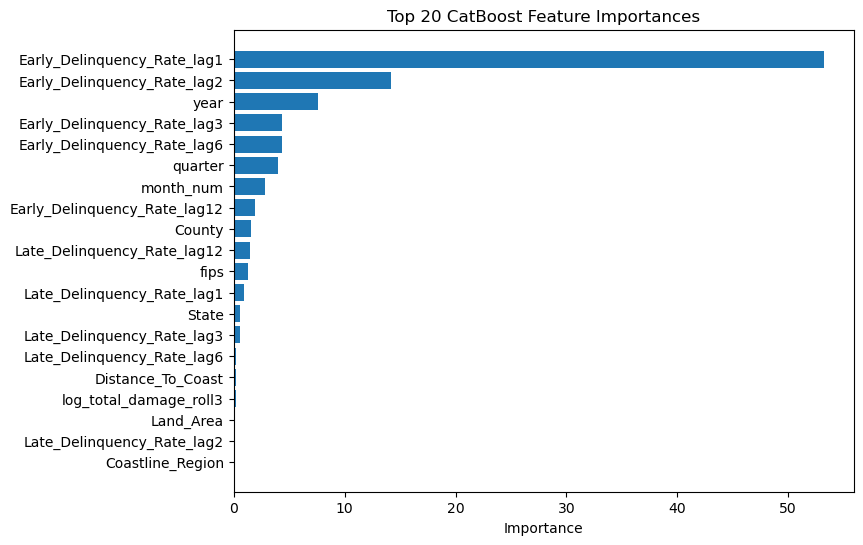

In [120]:
feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": cat_model.get_feature_importance()
}).sort_values("importance", ascending=False)

top_imp = feature_importance.head(20).iloc[::-1]

plt.figure(figsize=(8, 6))
plt.barh(top_imp["feature"], top_imp["importance"])
plt.title("Top 20 CatBoost Feature Importances")
plt.xlabel("Importance")
plt.show()

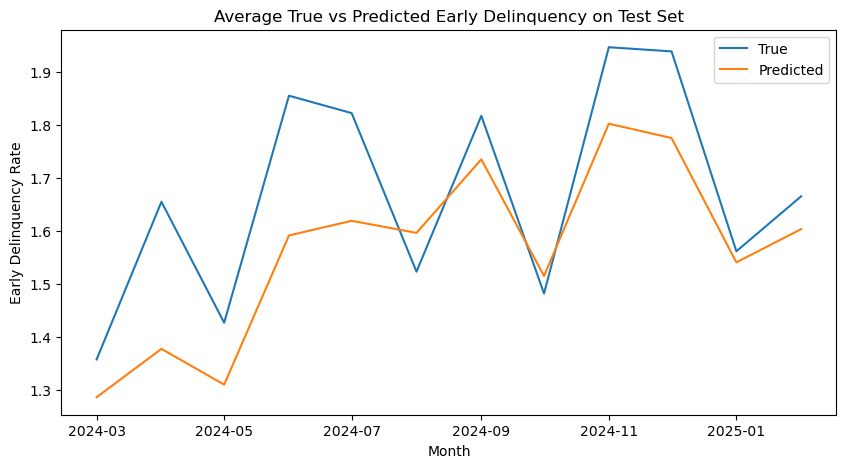

In [122]:
pred_df = test_df[["fips", "County", "month"]].copy()
pred_df["y_true"] = y_test.values
pred_df["y_pred"] = test_pred

monthly_perf = pred_df.groupby("month")[["y_true", "y_pred"]].mean()

plt.figure(figsize=(10, 5))
plt.plot(monthly_perf.index, monthly_perf["y_true"], label="True")
plt.plot(monthly_perf.index, monthly_perf["y_pred"], label="Predicted")
plt.title("Average True vs Predicted Early Delinquency on Test Set")
plt.xlabel("Month")
plt.ylabel("Early Delinquency Rate")
plt.legend()
plt.show()